In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from tqdm import tqdm

import lightgbm as lgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import roc_curve

# 윈도우 기본 한글 폰트 설정
mpl.rcParams["font.family"] = "Malgun Gothic"  # 맑은 고딕 사용

# 마이너스 깨짐 방지
mpl.rcParams["axes.unicode_minus"] = False  # 음수 기호 정상 출력

In [2]:
# 데이터 및 분석기 로드
df = pd.read_csv(r'F:\porti\2026\Control_Defines_Difficulty\Control_Defines_Difficulty\3_comment_original\ALL_out\all_merged_comments.csv')
df

,selftext,source,region
0,워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드,dcinside_aion2,국내
1,그냥 대가리박고 십부장템 너프하죠?,dcinside_aion2,국내
2,마도성 pve좋다 좋다 하는데,dcinside_aion2,국내
3,와 호법은 진짜 초월고단계지옥이네,dcinside_aion2,국내
4,배럭 막았음 좋겠네,dcinside_aion2,국내
...,...,...,...
14928,ㅄ같은 마사지를 보았습니다,youtube,국내
14929,아니 엔진 하나 바꾼다고 이렇게 퀄이 좋냐고!,youtube,국내
14930,lets gooooooo plz don't make same mistakes yo...,youtube,국내
14931,클베 언제인지 아시나요?,youtube,국내


In [3]:
# 전처리 확인 - 중복, 빈 텍스트, 어느 나라 언어인지 확인 칼럼 추가
# 언어 판별 컬럼 추가
from langdetect import detect

def detect_korean_custom(text):

    if pd.isna(text):
        return "unknown"
    
    text = str(text).strip()

    if text == "":
        return "unknown"

    # 한글 포함은 무조건 한국어
    if re.search(r"[가-힣]", text):
        return "ko"

    # 디시식 표현
    dc_patterns = ["ㅇ", "ㅁㅌㅊ", "ㅅㅂ", "ㄹㅇ", "ㅇㅇ", "ㅇㅅㅇ", "ㄱㄱ", "ㅎ", "ㅎㅎㅎ"]
    for p in dc_patterns:
        if p in text:
            return "ko"

    # 영어만 있는 경우
    if re.fullmatch(r"[a-zA-Z0-9\s\W]+", text):
        return "en"

    # fallback (기타 언어)
    try:
        if text.strip() == " ":
            return "unknown"
        return detect(text)
    except:
        return "error"


df["language"] = df["selftext"].apply(detect_korean_custom)

print("\n언어 분포:")
print(df["language"].value_counts())


언어 분포:
ko         14135
en           713
ru            36
es             8
pt             7
fr             6
tr             4
ar             4
zh-cn          4
unknown        4
fa             3
bg             3
uk             2
ja             1
mk             1
sl             1
hr             1
Name: language, dtype: int64


In [4]:
print(f"전체 데이터 수: {len(df)}")

# 중복 조회
duplicates = df[df.duplicated(subset=["selftext","source","region"], keep=False)]
print(f"\n중복 데이터 수: {len(duplicates)}")
print(duplicates.head())

# 빈 텍스트 조회
df["selftext"] = df["selftext"].fillna("").astype(str)
empty_rows = df[df["selftext"].str.strip() == ""]
print(f"\n빈 텍스트 수: {len(empty_rows)}")
print(empty_rows.head())

# 링크 포함 조회
link_rows = df[df["selftext"].str.contains("http|https", case=False, na=False)]
print(f"\n링크 포함 데이터 수: {len(link_rows)}")
print(link_rows.head())

전체 데이터 수: 14933

중복 데이터 수: 0
Empty DataFrame
Columns: [selftext, source, region, language]
Index: []

빈 텍스트 수: 4
     selftext           source region language
6774               inven_aion2     국내  unknown
6981             reddit_MMORPG     해외  unknown
7048           reddit_Aion2Hub     해외  unknown
7062              reddit_Aion2     해외  unknown

링크 포함 데이터 수: 0
Empty DataFrame
Columns: [selftext, source, region, language]
Index: []


In [14]:
# 빈 텍스트 제거
df["selftext"] = df["selftext"].fillna("").astype(str)
df = df[df["selftext"].str.strip() != ""]

print(f"\n빈 텍스트 제거 후 데이터 수: {len(df)}")


빈 텍스트 제거 후 데이터 수: 14929


In [15]:
# 언어 분포 (카운트 + 비중)
lang_counts = df["language"].value_counts()
lang_ratio = df["language"].value_counts(normalize=True) * 100

lang_summary = pd.DataFrame({
    "count": lang_counts,
    "ratio(%)": lang_ratio.round(2)
})

print("\n언어 분포:")
print(lang_summary)

# 한국어 아닌 데이터 조회
non_korean = df[df["language"] != "ko"]

print(f"\n한국어 아닌 데이터 수: {len(non_korean)} ({len(non_korean)/len(df)*100:.2f}%)")
non_korean


언어 분포:
       count  ratio(%)
ko     14135     94.68
en       712      4.77
ru        36      0.24
pt         8      0.05
es         8      0.05
fr         6      0.04
zh-cn      4      0.03
ar         4      0.03
tr         4      0.03
fa         3      0.02
bg         3      0.02
uk         2      0.01
ja         1      0.01
mk         1      0.01
sl         1      0.01
hr         1      0.01

한국어 아닌 데이터 수: 794 (5.32%)


,selftext,source,region,language
4594,131,dcinside_aion2,국내,en
4602,xx,dcinside_aion2,국내,en
5195,PTSD,dcinside_lostarkm,국내,en
5797,5090,dcinside_lostarkm,국내,en
5927,S25U 16G,dcinside_lostarkm,국내,en
...,...,...,...,...
14808,I will never play this on Mobile.,youtube,국내,en
14810,just another gacha mmo,youtube,국내,en
14820,Hope the mobile version makes u to progress th...,youtube,국내,en
14824,هتكسر الدنيا على الموبايل اللعبه,youtube,국내,ar


In [17]:
# 번역 테스트용 저장
output_path = "merged_comments_global_translate.csv"
non_korean.to_csv(output_path, index=False, encoding="utf-8-sig")

In [19]:
# 한국어 비중이 약 95%로 한국어 댓글만 사용해도 합리하다고 생각
# 한국어만 필터링
df_ko = df[df["language"] == "ko"]
print(f"한국어 데이터 수: {len(df_ko)} ({len(df_ko)/len(df)*100:.2f}%)")

# 저장
OUTPUT_PATH = "all_merged_comments_korean_only.csv"
df_ko.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"\n한국어 데이터 저장 완료: {OUTPUT_PATH}")
df_ko

한국어 데이터 수: 14135 (94.68%)

한국어 데이터 저장 완료: all_merged_comments_korean_only.csv


,selftext,source,region,language
0,워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드,dcinside_aion2,국내,ko
1,그냥 대가리박고 십부장템 너프하죠?,dcinside_aion2,국내,ko
2,마도성 pve좋다 좋다 하는데,dcinside_aion2,국내,ko
3,와 호법은 진짜 초월고단계지옥이네,dcinside_aion2,국내,ko
4,배럭 막았음 좋겠네,dcinside_aion2,국내,ko
...,...,...,...,...
14927,아크라시아가 멸망하는 운명,youtube,국내,ko
14928,ㅄ같은 마사지를 보았습니다,youtube,국내,ko
14929,아니 엔진 하나 바꾼다고 이렇게 퀄이 좋냐고!,youtube,국내,ko
14931,클베 언제인지 아시나요?,youtube,국내,ko


In [3]:
df = pd.read_csv(r'F:\porti\2026\Control_Defines_Difficulty\Control_Defines_Difficulty\3_comment_original\ALL_out\all_merged_comments_korean_only.csv')
df

,selftext,source,region,language
0,워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드,dcinside_aion2,국내,ko
1,그냥 대가리박고 십부장템 너프하죠?,dcinside_aion2,국내,ko
2,마도성 pve좋다 좋다 하는데,dcinside_aion2,국내,ko
3,와 호법은 진짜 초월고단계지옥이네,dcinside_aion2,국내,ko
4,배럭 막았음 좋겠네,dcinside_aion2,국내,ko
...,...,...,...,...
14130,아크라시아가 멸망하는 운명,youtube,국내,ko
14131,ㅄ같은 마사지를 보았습니다,youtube,국내,ko
14132,아니 엔진 하나 바꾼다고 이렇게 퀄이 좋냐고!,youtube,국내,ko
14133,클베 언제인지 아시나요?,youtube,국내,ko


In [188]:
keywords = {
    "난이도_높음": [
        "추락", "어렵", "힘들", "빡세", "헬", "스트레스", "지옥", "고통", "다터졌네", "만점", 
        "쉽지않", "레벨링", "썰자팟", "지옥", "초월", "고단계", "숨이 막히", "피로도",
        "원거리쟁","못잡", "미친놈", "오래걸림", "쉽지 않네", "피통", "올려야"
    ],
    "난이도_낮음": [
        "쩔", "공유", "솔플", "무난", "촌섭", "편함", "할만", "쉬움", "널널", "버스", 
        "주작", "빨리올리는", "꿀팁", "개사기네", "무한힐", "효율", "딸깍", "개꿀",
        "금방이네", "편하","평타만", "쉬웠는", "학살", "가볍게", "시골", "렙업", 
        "뻥투력", "딜러", "낮아", "마도사", "16렙", "치유"
    ],
    "조작_복잡": [
        "시프트", "조작", "컨트롤", "손", "피로", "바쁘", "복잡", "손아픔", "손꼬임", 
        "피지컬", "연타", "멀티태스킹", "정신없", "클릭", "터치", "옵션", "스킬창", "스킬북",
        "종료버튼이 없냐", "스킬", "마우스", "키보드", "ASDF", "QWER", "걸림", "pvp", "on",
        "낙사", "기절", "게이지", "원거리", "적폐"
    ],
    "조작_간단": [
        "간단", "편함", "단순", "쉬운조작", "편한조작", "직관적", "적응쉬움", "금방익힘", 
        "편의성", "자동", "원터치", "빡숙"
    ],
    "입력_과다": [
        "버튼 많", "입력 많", "손 많이", "눌러야", "조작 많", "복잡 입력", "버튼빡셈", 
        "손바쁨", "광클", "연사", "키보드박살", "노가다", "양학", "파밍"
    ],
    "입력_적음": [
        "버튼 적", "간단 입력", "조작 적", "입력 적", "간편", "편한 입력", "조작 최소", 
        "부담없음", "간결"
    ],
    "반응_실패": [
        "못피", "늦", "반응 못", "못피함", "대응 못", "반응 느림", "타이밍 실패", "못막", "놓침",
        "따먹히는데", "관심없", "이해가 안가", "멀미", "로붕", "원툴", "병신겜", "모욕", "제한", "최악", "즉사",
        "무반응", "유배", "운빨"
    ],
    "반응_성공": [
        "피했", "잘 피", "회피 성공", "잘막", "대응 가능", "컨 성공", "피하기 쉬움", "회피 잘됨", "컨 잘됨",
        "잘한거임", "몇트", "빠르게"
    ],
    "전투_실패": [
        "어글", "어그로", "피격", "죽", "터짐", "녹음", "순삭", "한방", "끔살", "삭제됨", "너프", "거지같", "밸런스붕괴",
        "못깨요", "못잡", "불신", "올드한", "주고 받는", "전투가 답답", "트롤", "진다", "징징", "투력", "무쓸모", "쟁"
    ],
    "전투_성공": [
        "안맞", "버팀", "살았", "생존", "안죽", "버티기", "유지됨", "클리어", "안맞음", "보상", "성능", "사기급",
        "던전 패싱", "레이드", "전투 디자인 잘했네"
    ],
    "자동화_의존": [
        "매크로", "오토", "자동사냥", "자동", "어뷰", "어뷰징", "버그", "자동플레이", "오토플", "딸깍겜",
        "메크로", "작업장", "막혔네", "자사", "쌀먹", "무능", "설사"
    ],
    "수동_플레이": [
        "시프트", "수동", "직접", "손컨", "수동플", "직접조작", "몰이사냥", "직접함", "컨트롤함", "손맛",
        "시공", "봉던", "원정", "채집 실패", "탐험", "몰입감", "리니지라이크", "리니지 라이크", "비행", "투력컷", "펫작",
        "포기", "폐지", "평캔"
    ],
    "부정_경험": [
        "던져버리노", "틀딱들", "손봐야", "개버러지", "씹버러지", "틀딱", "못만들", "실망", "짜증", 
        "불만", "답도 없", "추방", "우습다", "쫓겨났음", "쫒겨났음", "최적화", "렉", "발열", "그래픽왜이럼", "망겜",
        "노안", "다운증후군","재미없", "모자라", "잘못됐음", "안됌", "에바", "또라이", "망함", "소통없",
        "뭐함", "미침", "노잼", "스킵 안되는", "크래시", "구림", "부족하", "안하는", "안나옴", "없네",
        "터졌네", "뭐임", "분탕", "안 본다", "숨막혀", "이제와서", "후려친", "노후한", "없는","안까고",
        "안됨", "짜치던데", "느리", "불확실", "욕처먹", "구려", "짜침", "한심하네", "개고기", "똑같",
        "재미는없음", "속지마", "믿지마", "안믿", "아쉽", "불편", "망한다", "늙고", "않고", "못하",
        "망할", "망해", "짜치네","안기다렸어", "장난", "않았다", "멈춰있", "감다뒤", "적자", "꼴아박은", "망했",
        "아니다", "망한", "망해서", "하기싫은", "착각", "토나오", "겨우 이거", "멍청한", "어색한", "중국풍",
        "후져서", "별로", "굳이", "바꿔", "급하게", "없었습니다", "중국게임", "이게끝", "안팜", "안냄", "망조",
        "판박", "믿거", "이따구로", "습슬","하지말고","역겨", "심함", "화나네", "안돼", "양산", "몬데", "쓰레기",
        "하지않", "망하기", "완자", "피곤함", "짜쳐", "접었다", "타락", "욕먹을", "혐오", "돈독", "쳐먹", "쌍팔년도",
        "구시대", "모름", "방생", "적대적", "싫어", "증오", "저주", "망령", "믿고 거", "없겠지", "화가 많","화날텐데",
        "이딴소리", "아재", "망하겠죠", "답 없음", "답답", "별론", "쳐잔다", "안생김", "아니잖아", "대충", "개떡", "호구",
        "뻔하지", "극혐", "폭탄", "분노", "사내정치", "흑우", "심하잖아", "말아먹기", "중국", "졸고", "꼬라지", "허접",
        "비슷", "구리", "똥겜", "맛없다", "폐망", "몰락", "걸러", "돈아까워", "비싼", "도망가", "안사", "도박", "퇴출", "쳐망하는",
        "안해", "기대되지 않는", "과금", "믿을수가없다", "나락", "현질", "노답", "없어", "안속", "짜쳤음", "또속", "한심해", "안 함",
        "지겹", "기대마", "또 속", "상술", "급락", "안 돼", "못함", "너무해", "겉돌", "짭", "재미가없", "내려가", "답이없", "종료",
        "안되", "그닥", "개똥", "영포티", "안댐", "짜친", "애매", "더럽", "힘듬", "알바", "힘드네", "허언증", "안느껴짐", "그만",
        "불쾌", "아니네", "안함", "빡치", "논란", "대기열", "쳐발리", "털리", "싫다", "안타까움", "지루", "화남", "잘못", "꼬장",
        "충", "겜안분", "못느끼겠네", "잡치", "삭제", "접으", "난잡", "저따구", "없다", "가지마", "오지마", "사기", "함정"
    ],
    "긍정_경험": [
        "재밌노", "신기한데", "재미떠", "꿀잼", "존나재밌음", "갓겜", "재밌다", "추천", "좋다", 
        "잘만들긴했다", "할만하", "재밌겠다", "괜찮", "발전했네", "혜자", "귀엽", "좋네",
        "개추", "재밌는데", "맘에들긴함","편하", "웅장", "좋게 봤습니다", "재밌겠지",
        "새롭다", "폼 미쳤다", "기대해", "잘나왔다", "탑인듯", "신기하네","기대됩","기대합","잼난듯", "적합",
        "좋고", "해봐야겠네", "즐겨", "예쁘네", "낭만", "감성", "갬성미 미쳤", "가볼만해", "즐기면되죠", "즐겜",
        "대단", "힘내", "재밌네", "건전한", "흥해서", "이쁘네", "볼만 하겠", "대박", "좋겠", "할수잇다",
        "잘빠", "좋은데", "간지난다", "좋을거 같다", "하고싶다", "신기하다", "재밌어", "잘만", "해보고싶다",
        "잘나왓", "잘나왔", "잘됐", "하고 싶어", "잘구현했", "기대가 되네", "재미있어", "잘나옴", "잼께따",
        "졸잼", "혁신", "잘했네", "재밌겄다", "우월", "할수잇겠다", "잘했나봐", "재밌었", "기깔나네", "좋아한다", "좋음",
        "좋아보이", "나은데", "잼있겠다", "재밋어", "평타 이상", "예뻐서", "확실한", "잘나온거", "기대된다", "신박해", "좋아",
        "갓게임", "잘 뽑", "이쁘다", "멋있어", "멋집", "감사", "안도", "잼있었지", "하고싶", "예쁜데", "놀라움", "설렌다",
        "잘 만듬", "멋있다", "원활", "놀랍습니다", "생동감", "매끄럽", "기쁜", "좋았", "새로운", "즐거운", "기쁩", "화려",
        "기대", "흥행", "재밌긴", "잼있넹", "잘 만든", "많은데", "최고", "극찬", "존잼", "재미지구나", "귀여운", "지린다", "맘에든다",
        "높은", "맘에드노"
    ]
}

In [189]:
# 계산 그룹 정의
pos_cols = ["난이도_낮음", "조작_간단", "입력_적음", "반응_성공", "전투_성공", "수동_플레이", "긍정_경험"]
neg_cols = ["난이도_높음", "조작_복잡", "입력_과다", "반응_실패", "전투_실패", "자동화_의존", "부정_경험"]

#  행별 분석 함수
def analyze_row(text):
    text = str(text).lower()
    counts = {k: sum(1 for w in words if re.search(re.escape(w), text)) for k, words in keywords.items()}
    
    p_sum = sum(counts[col] for col in pos_cols)
    n_sum = sum(counts[col] for col in neg_cols)
    total = p_sum + n_sum
    
    if total == 0:
        return pd.Series(["중립", "기타", "0.00%", "100.00%", "0.00%"], 
                         index=["sentiment", "category", "positive_ratio", "neutral_ratio", "negative_ratio"])
    
    label = "긍정" if p_sum > n_sum else ("부정" if n_sum > p_sum else "중립")
    category = max(counts, key=counts.get)
    
    return pd.Series([label, category, f"{(p_sum/total*100):.2f}%", "0.00%", f"{(n_sum/total*100):.2f}%"], 
                     index=["sentiment", "category", "positive_ratio", "neutral_ratio", "negative_ratio"])

# 실행 및 결과 합치기
# 기존 결과 컬럼 삭제 후 새로 계산
df = df.drop(columns=["sentiment", "category", "positive_ratio", "neutral_ratio", "negative_ratio"], errors='ignore')
analysis_results = df["selftext"].apply(analyze_row)
df = pd.concat([df, analysis_results], axis=1)

# 결과 출력창
print("\n" + "="*95)
print(f"{'댓글 내용 (selftext)':<50} | {'감정':<4} | {'긍정%':<8} | {'부정%':<8}")
print("-" * 95)

# 상위 15개 샘플 출력
for _, r in df.head(15).iterrows():
    txt = str(r['selftext']).replace('\n', ' ')[:48]
    print(f"{txt:<50} | {r['sentiment']:<4} | {r['positive_ratio']:<8} | {r['negative_ratio']:<8}")

print("="*95)

# 전체 통계
sent_val = df["sentiment"].value_counts(normalize=True) * 100
print(f"[전체 요약]  긍정: {sent_val.get('긍정',0):.2f}% | 부정: {sent_val.get('부정',0):.2f}% | 중립: {sent_val.get('중립',0):.2f}%")
print(f"Complaint Score: {sent_val.get('부정',0):.2f}")
print("="*95)


댓글 내용 (selftext)                                   | 감정   | 긍정%      | 부정%     
-----------------------------------------------------------------------------------------------
워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드                    | 중립   | 0.00%    | 0.00%   
그냥 대가리박고 십부장템 너프하죠?                                | 부정   | 0.00%    | 100.00% 
마도성 pve좋다 좋다 하는데                                   | 긍정   | 100.00%  | 0.00%   
와 호법은 진짜 초월고단계지옥이네                                 | 부정   | 0.00%    | 100.00% 
배럭 막았음 좋겠네                                         | 긍정   | 100.00%  | 0.00%   
원정 큐브안까고 뺑빼이 돌아도댐?                                 | 중립   | 50.00%   | 50.00%  
커마 ㅁㅌㅊ?                                            | 중립   | 0.00%    | 0.00%   
왜 로리커마 90%는 다운증후군같이 만드는거냐?                         | 부정   | 0.00%    | 100.00% 
부활석은 지금이 밸런스가 최고 좋음                                | 긍정   | 100.00%  | 0.00%   
모든 살성이 다 pve 1.5인분 하는건 아니다                         | 부정   | 0.00%    | 100.00% 
국민 매크로 게임이 된건 궁성짤 주인공이 

In [190]:
print("\n" + "="*50)
print("[전체 통계 요약]")
print("="*50)
sent_counts = df["sentiment"].value_counts(normalize=True) * 100
for label, ratio in sent_counts.items():
    print(f"{label} 비중: {ratio:.2f}%")

complaint_score = (df["sentiment"] == "부정").mean() * 100
print(f"Final Complaint Score: {complaint_score:.2f}")
print("="*50)


[전체 통계 요약]
중립 비중: 55.64%
부정 비중: 30.44%
긍정 비중: 13.92%
Final Complaint Score: 30.44


In [191]:
df

,selftext,source,region,language,sentiment,category,positive_ratio,neutral_ratio,negative_ratio
0,워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%
1,그냥 대가리박고 십부장템 너프하죠?,dcinside_aion2,국내,ko,부정,전투_실패,0.00%,0.00%,100.00%
2,마도성 pve좋다 좋다 하는데,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%
3,와 호법은 진짜 초월고단계지옥이네,dcinside_aion2,국내,ko,부정,난이도_높음,0.00%,0.00%,100.00%
4,배럭 막았음 좋겠네,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%
...,...,...,...,...,...,...,...,...,...
14130,아크라시아가 멸망하는 운명,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%
14131,ㅄ같은 마사지를 보았습니다,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%
14132,아니 엔진 하나 바꾼다고 이렇게 퀄이 좋냐고!,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%
14133,클베 언제인지 아시나요?,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%


In [ ]:
# 임시 테스트용 저장
output_path = "merge_comment_test.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

In [192]:
# 확인용
df_neutral = df[df["category"] == "기타"].copy()

In [193]:
df_neutral

,selftext,source,region,language,sentiment,category,positive_ratio,neutral_ratio,negative_ratio
0,워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%
6,커마 ㅁㅌㅊ?,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%
12,십부장사는거 좋은거 맞냐,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%
14,S 클목적이라며 시발,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%
16,로-아도 그렇더만 이겜도 근본적 시스템부터 묘한게 많네,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%
...,...,...,...,...,...,...,...,...,...
14130,아크라시아가 멸망하는 운명,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%
14131,ㅄ같은 마사지를 보았습니다,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%
14132,아니 엔진 하나 바꾼다고 이렇게 퀄이 좋냐고!,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%
14133,클베 언제인지 아시나요?,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%


In [30]:
df = pd.read_csv(r'F:\porti\2026\Control_Defines_Difficulty\Control_Defines_Difficulty\3_comment_original\ALL_out\all_merged_comments_korean_only.csv')
df

,selftext,source,region,language,sentiment,category,positive_ratio,neutral_ratio,negative_ratio
0,워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%
1,그냥 대가리박고 십부장템 너프하죠?,dcinside_aion2,국내,ko,부정,전투_실패,0.00%,0.00%,100.00%
2,마도성 pve좋다 좋다 하는데,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%
3,와 호법은 진짜 초월고단계지옥이네,dcinside_aion2,국내,ko,부정,난이도_높음,0.00%,0.00%,100.00%
4,배럭 막았음 좋겠네,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%
...,...,...,...,...,...,...,...,...,...
14130,아크라시아가 멸망하는 운명,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%
14131,ㅄ같은 마사지를 보았습니다,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%
14132,아니 엔진 하나 바꾼다고 이렇게 퀄이 좋냐고!,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%
14133,클베 언제인지 아시나요?,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%


In [40]:
# 1. Sensitive 그룹별 패턴 정의 (여러 줄로 관리)

# [A] 정치 및 특정 국가 혐오 그룹
politics_hate_list = [
    "이재명", "윤석열", "문재인", "노무현", "박근혜", "홍준표", "한동훈", "전재명", 
    "민주당", "국힘", "개딸", "대깨", "좌빨", "우좀", "문재앙", "윤무당", "찢", "정치적",
    "중국", "짱깨", "짱개", "중궈", "착짱", "짱꿔", "샤오미", "공산당", "김치",
    "민주주의", "독재", "짱겜", "짱ㄲ"
]
p_politics = "|".join(politics_hate_list)

# [B] 욕설 그룹 (지정한 초성의 '사잇글자' 변형 포함)
# .? 는 한 글자, .* 는 여러 글자가 중간에 들어오는 것을 허용합니다.
abuse_list = [
    # 지정하신 핵심 초성 패턴 (중간에 어떤 문자가 와도 매칭)
    r"ㅅ.{0,2}ㅂ", r"ㅈ.{0,2}ㄹ", r"ㅆ.{0,2}ㅂ", r"ㅆ.{0,2}ㅃ", r"ㅅ.{0,2}ㅃ", r"ㅉ.{0,2}ㄹ", r"ㅄ", r"ㅂ.{0,2}ㅅ", r"ㅅㄲ", r"ㅈㄴ",
    # 일반 단어형 욕설 변형
    r"[시씨ㅅ쉬싯슈섁개싯뛰].{0,2}[발바벌벌ㅂ팔Bㅍ박기줫병같좆펄]", r"지.{0,2}랄", r"[병븅비].{0,2}신", r"[존좆좃ㅈ].{0,2}[나됐구갈창되된같밥로망도노허]",
    # 패드립 및 비하
    r"애[미비]", r"니[애에][미비]", r"앰[창생]", r"느금마", r"뒤진", r"족제비년", r"에미", r"비융신", r"십새"
]
p_abuse = "|".join(abuse_list)

# [C] 비속어
slang_list = [
    r"짜치[ㄴ네려]", r"새[끼기키끼]", r"쌔[끼기키]", r"엿.{0,2}먹", 
    "미친[놈년]", "개[돼고]지", "버러지", "씹", "호구", "흑우", 
    "감다뒤", "뇌절", "능지", "빡대가리", "분탕", "꼴아박"
]
p_slang = "|".join(slang_list)

# 2. 통합 감지 함수
def get_sensitive_group(text):
    if pd.isna(text): return "False"
    # 분석 시에만 소문자화 (원문은 유지)
    text_to_check = str(text).lower()
    
    # 1순위: 정치/혐오
    if re.search(p_politics, text_to_check):
        return "정치/혐오"
    
    # 2순위: 욕설 (초성 사잇글자 포함)
    if re.search(p_abuse, text_to_check):
        return "욕설"
    
    # 3순위: 비속어
    if re.search(p_slang, text_to_check):
        return "비속어"
        
    return "False"

# 3. 데이터프레임 적용
df['sensitive_group'] = df['selftext'].apply(get_sensitive_group)
df['sensitive_flag'] = df['sensitive_group'] != "False"

# ---------------------------------------------------------
# 4. 검증 함수: sensitive_flag = False(정상) 데이터 확인
# ---------------------------------------------------------
def check_clean_list(dataframe, count=50):
    clean_df = dataframe[dataframe['sensitive_flag'] == False]
    
    print("\n" + "="*95)
    print(f"🟢 [Clean Data 검토] 필터링을 통과한 '정상' 데이터 (총 {len(clean_df)}건)")
    print("-" * 95)
    
    for idx, row in clean_df.head(count).iterrows():
        content = str(row['selftext']).replace('\n', ' ')
        print(f"ID: {idx:<6} | {content[:80]}...")
        
    print("-" * 95)
    print(f"💡 분석: ㅋㅋ, ㅠㅠ, ㅜㅜ 등이 보이고 욕설이 없으면 성공입니다.")
    print("="*95)
    return clean_df

# 5. 실행
clean_samples = check_clean_list(df)
clean_samples
# 필터링 통계
print(f"\n🚨 그룹별 탐지 결과:\n{df['sensitive_group'].value_counts()}")


🟢 [Clean Data 검토] 필터링을 통과한 '정상' 데이터 (총 12169건)
-----------------------------------------------------------------------------------------------
ID: 0      | 워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드...
ID: 1      | 그냥 대가리박고 십부장템 너프하죠?...
ID: 2      | 마도성 pve좋다 좋다 하는데...
ID: 3      | 와 호법은 진짜 초월고단계지옥이네...
ID: 4      | 배럭 막았음 좋겠네...
ID: 5      | 원정 큐브안까고 뺑빼이 돌아도댐?...
ID: 6      | 커마 ㅁㅌㅊ?...
ID: 7      | 왜 로리커마 90%는 다운증후군같이 만드는거냐?...
ID: 8      | 부활석은 지금이 밸런스가 최고 좋음...
ID: 9      | 모든 살성이 다 pve 1.5인분 하는건 아니다...
ID: 10     | 국민 매크로 게임이 된건 궁성짤 주인공이 한몫함...
ID: 11     | 오드에너지 다쓰면 님들뭐함?...
ID: 12     | 십부장사는거 좋은거 맞냐...
ID: 13     | 근데 배럭 효율도 그닥이네...
ID: 15     | 솔직히 이건 확률조작 맞음...
ID: 16     | 로-아도 그렇더만 이겜도 근본적 시스템부터 묘한게 많네...
ID: 17     | 딜컷 4인 도핑+봉혼석 기준일거임...
ID: 18     | 시엘섭인데 아리엘도 45짜리있거든??...
ID: 19     | 야 불신 2300끼린 절대 못깨냐?...
ID: 20     | 매크로는 어떤겜이든 못잡는다.근들갑 떨지마라...
ID: 22     | 불신 방장특)...
ID: 23     | 너희들 지금 부활석 몇개씩 갖고있냐? 중간점검해보자...
ID: 24     | 장신구에는 영혼각인 다 액티브스킬임?...
ID: 26     | 생각해 봤는데 뉴비 학살이

In [41]:
# 확인용
df_neutral = df[df['sensitive_flag'] == False].copy()

In [42]:
df_neutral

,selftext,source,region,language,sentiment,category,positive_ratio,neutral_ratio,negative_ratio,sensitive_group,sensitive_flag
0,워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False
1,그냥 대가리박고 십부장템 너프하죠?,dcinside_aion2,국내,ko,부정,전투_실패,0.00%,0.00%,100.00%,False,False
2,마도성 pve좋다 좋다 하는데,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%,False,False
3,와 호법은 진짜 초월고단계지옥이네,dcinside_aion2,국내,ko,부정,난이도_높음,0.00%,0.00%,100.00%,False,False
4,배럭 막았음 좋겠네,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%,False,False
...,...,...,...,...,...,...,...,...,...,...,...
14129,오우 미쳤구만 미쳤어,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False
14130,아크라시아가 멸망하는 운명,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False
14132,아니 엔진 하나 바꾼다고 이렇게 퀄이 좋냐고!,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False
14133,클베 언제인지 아시나요?,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False


In [43]:
# 임시 저장
OUTPUT_PATH = "df_neutral.csv"
df_neutral.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

In [44]:
OUTPUT_PATH = r'F:\porti\2026\Control_Defines_Difficulty\Control_Defines_Difficulty\3_comment_original\ALL_out\all_merged_comments_korean_only.csv'
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

In [2]:
df = pd.read_csv(r'F:\porti\2026\Control_Defines_Difficulty\Control_Defines_Difficulty\3_comment_original\ALL_out\all_merged_comments_korean_only.csv')
df

,selftext,source,region,language,sentiment,category,positive_ratio,neutral_ratio,negative_ratio,sensitive_group,sensitive_flag
0,워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False
1,그냥 대가리박고 십부장템 너프하죠?,dcinside_aion2,국내,ko,부정,전투_실패,0.00%,0.00%,100.00%,False,False
2,마도성 pve좋다 좋다 하는데,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%,False,False
3,와 호법은 진짜 초월고단계지옥이네,dcinside_aion2,국내,ko,부정,난이도_높음,0.00%,0.00%,100.00%,False,False
4,배럭 막았음 좋겠네,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%,False,False
...,...,...,...,...,...,...,...,...,...,...,...
14130,아크라시아가 멸망하는 운명,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False
14131,ㅄ같은 마사지를 보았습니다,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,욕설,True
14132,아니 엔진 하나 바꾼다고 이렇게 퀄이 좋냐고!,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False
14133,클베 언제인지 아시나요?,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False


In [3]:
df.columns

Index(['selftext', 'source', 'region', 'language', 'sentiment', 'category',
       'positive_ratio', 'neutral_ratio', 'negative_ratio', 'sensitive_group',
       'sensitive_flag'],
      dtype='object')

In [4]:
print("데이터 확인")
print(df.columns)
print(f"총 데이터 수: {len(df)}")

데이터 확인
Index(['selftext', 'source', 'region', 'language', 'sentiment', 'category',
       'positive_ratio', 'neutral_ratio', 'negative_ratio', 'sensitive_group',
       'sensitive_flag'],
      dtype='object')
총 데이터 수: 14135


In [5]:
# CCS 레벨 정의 (category 기반)

ccs_high = ["조작_복잡", "입력_과다", "반응_실패"]
ccs_low = ["조작_간단", "입력_적음", "반응_성공"]

def map_ccs(cat):
    if cat in ccs_high:
        return "높음"
    elif cat in ccs_low:
        return "낮음"
    else:
        return "중간"

df["ccs_level"] = df["category"].apply(map_ccs)

In [6]:
# 행동 패턴 정의
def behavior_map(cat):
    if cat in ["반응_실패", "전투_실패"]:
        return "회피포기"
    elif cat in ["입력_적음", "조작_간단"]:
        return "전략단순화"
    elif cat == "자동화_의존":
        return "자동의존"
    else:
        return "기타"

df["behavior"] = df["category"].apply(behavior_map)

# 자동화 여부
df["is_auto"] = df["category"] == "자동화_의존"

In [7]:
df

,selftext,source,region,language,sentiment,category,positive_ratio,neutral_ratio,negative_ratio,sensitive_group,sensitive_flag,ccs_level,behavior,is_auto
0,워프레임 신규 공포 콘텐츠 '그림자 화가' 무료 다운로드,dcinside_aion2,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False,중간,기타,False
1,그냥 대가리박고 십부장템 너프하죠?,dcinside_aion2,국내,ko,부정,전투_실패,0.00%,0.00%,100.00%,False,False,중간,회피포기,False
2,마도성 pve좋다 좋다 하는데,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%,False,False,중간,기타,False
3,와 호법은 진짜 초월고단계지옥이네,dcinside_aion2,국내,ko,부정,난이도_높음,0.00%,0.00%,100.00%,False,False,중간,기타,False
4,배럭 막았음 좋겠네,dcinside_aion2,국내,ko,긍정,긍정_경험,100.00%,0.00%,0.00%,False,False,중간,기타,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14130,아크라시아가 멸망하는 운명,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False,중간,기타,False
14131,ㅄ같은 마사지를 보았습니다,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,욕설,True,중간,기타,False
14132,아니 엔진 하나 바꾼다고 이렇게 퀄이 좋냐고!,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False,중간,기타,False
14133,클베 언제인지 아시나요?,youtube,국내,ko,중립,기타,0.00%,100.00%,0.00%,False,False,중간,기타,False


In [8]:
# 민감 데이터 제거 버전
df_clean = df[df["sensitive_flag"] == False]

print(f"\n클린 데이터 수: {len(df_clean)} ({len(df_clean)/len(df)*100:.2f}%)")


클린 데이터 수: 12169 (86.09%)


In [31]:
# 게임 구분 컬럼 추가
def map_game(source):
    source = str(source).lower()
    
    if "aion2" in source:
        return "aion2"
    elif "lostark" in source:
        return "lostarkmobile"
    else:
        return "other"

df["game"] = df["source"].apply(map_game)

# 혹시 모를 노이즈 제거
df = df[df["game"] != "other"]

# 그래프 비율 % 표시
def add_labels(ax):
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    height,
                    f"{height:.1f}%",
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

C:\Users\user\AppData\Local\Temp/ipykernel_21320/2347031846.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["game"] = df["source"].apply(map_game)



[CCS 수준 vs 감정]
sentiment     긍정     부정     중립
ccs_level                     
낮음         39.42  16.35  44.23
높음          1.41  87.30  11.29
중간         14.76  25.19  60.04


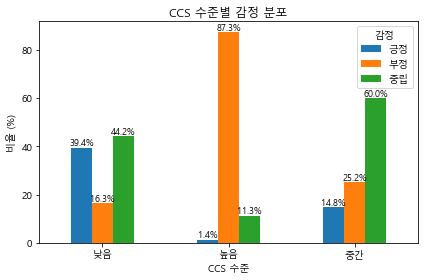

In [32]:
# CCS vs 감정 (난이도 체감)
print("\n" + "="*60)
print("[CCS 수준 vs 감정]")
print("="*60)

ccs_sent = pd.crosstab(df_clean["ccs_level"], df_clean["sentiment"], normalize="index") * 100
print(ccs_sent.round(2))

add_labels(ccs_sent.plot(kind="bar"))
plt.title("CCS 수준별 감정 분포")
plt.xlabel("CCS 수준")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="감정")
plt.tight_layout()
plt.show()


[CCS 수준 vs 행동 변화]
behavior      기타  자동의존  전략단순화   회피포기
ccs_level                           
낮음          6.73   0.0  93.27   0.00
높음         85.42   0.0   0.00  14.58
중간         93.17   3.9   0.00   2.92


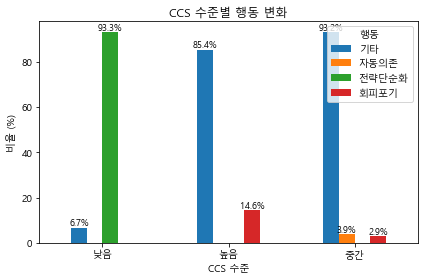

In [33]:
# CCS vs 행동 변화
print("\n" + "="*60)
print("[CCS 수준 vs 행동 변화]")
print("="*60)

ccs_behavior = pd.crosstab(df_clean["ccs_level"], df_clean["behavior"], normalize="index") * 100
print(ccs_behavior.round(2))

add_labels(ccs_behavior.plot(kind="bar"))
plt.title("CCS 수준별 행동 변화")
plt.xlabel("CCS 수준")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="행동")
plt.tight_layout()
plt.show()


[자동화 vs 감정]
sentiment     긍정     부정     중립
is_auto                       
False      14.79  25.88  59.33
True        0.67  93.95   5.38


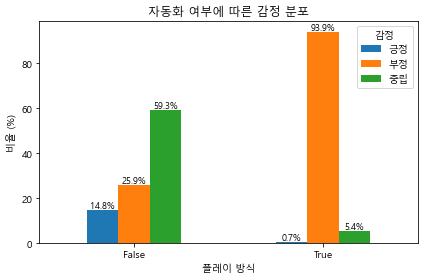

In [34]:
# 자동화 vs 감정
print("\n" + "="*60)
print("[자동화 vs 감정]")
print("="*60)

auto_sent = pd.crosstab(df_clean["is_auto"], df_clean["sentiment"], normalize="index") * 100
print(auto_sent.round(2))

add_labels(auto_sent.plot(kind="bar"))
plt.title("자동화 여부에 따른 감정 분포")
plt.xlabel("플레이 방식")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="감정")
plt.tight_layout()
plt.show()


[커뮤니티별 감정 분포]
source               sentiment
dcinside_aion2       중립           53.78
                     부정           31.21
                     긍정           15.01
dcinside_lostarkm    중립           71.51
                     부정           21.83
                     긍정            6.66
inven_aion2          중립           52.63
                     부정           31.58
                     긍정           15.79
inven_lostarkmobile  중립           45.74
                     긍정           44.68
                     부정            9.57
reddit_Aion2         중립           41.15
                     부정           39.58
                     긍정           19.27
reddit_Aion2Hub      중립           36.51
                     긍정           34.92
                     부정           28.57
reddit_MMORPG        부정           37.21
                     긍정           32.56
                     중립           30.23
youtube              중립           57.90
                     부정           28.18
                     긍정           

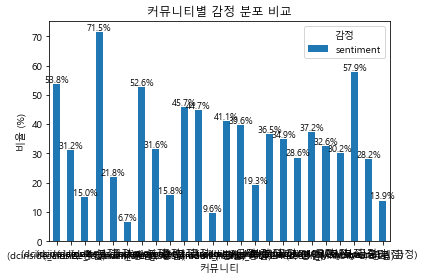

In [35]:
# 커뮤니티별 비교 (핵심)
print("\n" + "="*60)
print("[커뮤니티별 감정 분포]")
print("="*60)

game_sent = df_clean.groupby("source")["sentiment"].value_counts(normalize=True) * 100
print(game_sent.round(2))

print("\n" + "="*60)
print("[커뮤니티별 카테고리 분포]")
print("="*60)

game_cat = df_clean.groupby("source")["category"].value_counts(normalize=True) * 100
print(game_cat.round(2))

add_labels(game_sent.plot(kind="bar"))
plt.title("커뮤니티별 감정 분포 비교")
plt.xlabel("커뮤니티")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="감정")
plt.tight_layout()
plt.show()

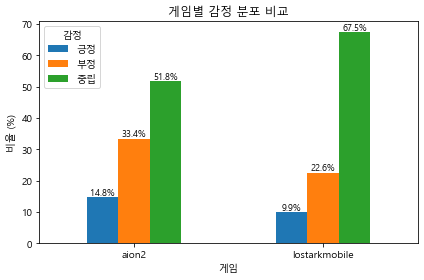

In [36]:
game_sent = df.groupby("game")["sentiment"].value_counts(normalize=True).unstack() * 100

add_labels(game_sent.plot(kind="bar"))
plt.title("게임별 감정 분포 비교")
plt.xlabel("게임")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="감정")
plt.tight_layout()
plt.show()

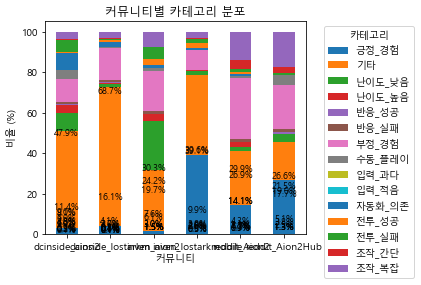

In [37]:
# 커뮤니티별 카테고리 분포
game_cat = df.groupby("source")["category"].value_counts(normalize=True).unstack().fillna(0) * 100

add_labels(game_cat.plot(kind="bar", stacked=True))
plt.title("커뮤니티별 카테고리 분포")
plt.xlabel("커뮤니티")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="카테고리", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

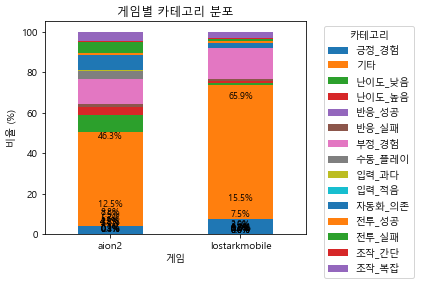

In [42]:
game_cat = df.groupby("game")["category"].value_counts(normalize=True).unstack().fillna(0) * 100

add_labels(game_cat.plot(kind="bar", stacked=True))
plt.title("게임별 카테고리 분포")
plt.xlabel("게임")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="카테고리", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


Complaint Score: 28.38


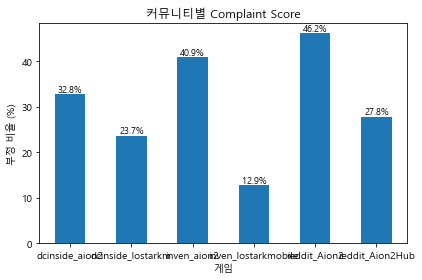

In [38]:
# Complaint Score
complaint_score = (df_clean["sentiment"] == "부정").mean() * 100
complaint = df.groupby("source")["sentiment"].apply(lambda x: (x=="부정").mean()*100)

print("\n" + "="*60)
print(f"Complaint Score: {complaint_score:.2f}")
print("="*60)

add_labels(complaint.plot(kind="bar"))
plt.title("커뮤니티별 Complaint Score")
plt.xlabel("게임")
plt.ylabel("부정 비율 (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

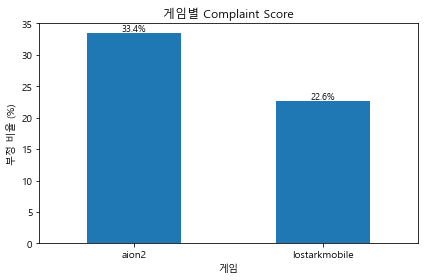

In [39]:
complaint = df.groupby("game")["sentiment"].apply(lambda x: (x=="부정").mean()*100)

add_labels(complaint.plot(kind="bar"))
plt.title("게임별 Complaint Score")
plt.xlabel("게임")
plt.ylabel("부정 비율 (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
# 핵심 검증 수치

# CCS 높음 → 부정 비율
ccs_high_df = df_clean[df_clean["ccs_level"] == "높음"]
high_negative_ratio = (ccs_high_df["sentiment"] == "부정").mean() * 100

# 자동화 → 긍정 비율
auto_df = df_clean[df_clean["is_auto"] == True]
auto_positive_ratio = (auto_df["sentiment"] == "긍정").mean() * 100

print("\n" + "="*60)
print("[핵심 검증 결과]")
print("="*60)
print(f"CCS 높음 -> 부정 비율: {high_negative_ratio:.2f}%")
print(f"자동화 사용 -> 긍정 비율: {auto_positive_ratio:.2f}%")
print("="*60)


[핵심 검증 결과]
CCS 높음 -> 부정 비율: 87.30%
자동화 사용 -> 긍정 비율: 0.67%


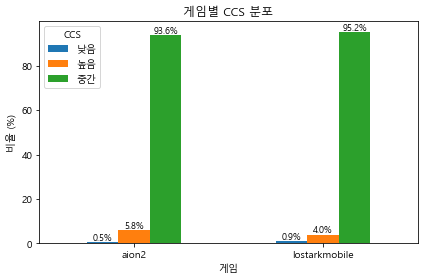

In [45]:
ccs_game = pd.crosstab(df["game"], df["ccs_level"], normalize="index") * 100

add_labels(ccs_game.plot(kind="bar"))
plt.title("게임별 CCS 분포")
plt.xlabel("게임")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="CCS")
plt.tight_layout()
plt.show()

In [15]:
# 정성 분석 샘플
print("\n[CCS 높음 샘플]")
print(df_clean[df_clean["ccs_level"] == "높음"]["selftext"].head(10))

print("\n[자동화 샘플]")
print(df_clean[df_clean["is_auto"] == True]["selftext"].head(10))


[CCS 높음 샘플]
15              솔직히 이건 확률조작 맞음
24        장신구에는 영혼각인 다 액티브스킬임?
41     근데 던전 입장 제한 수치는 손보긴 해야함
44     NC유저들은 제자리에서 스킬쓰는게 PVP임
55     검성 16레벨 액티브 스킬은 뭘로 잡나요?
125           일일키나 제한 200있긴하냐?
129        공중에서 원거리 폭격하는거 ㅈ사기네
151       Pvp 스턴 절감 효과가없음?????
155    갠적으로 스킬창 한 8개는 더줬으면 좋겠노
158       pvp 온 오프 넣어주면 안되냐 흑흑
Name: selftext, dtype: object

[자동화 샘플]
10         국민 매크로 게임이 된건 궁성짤 주인공이 한몫함
35                나만 오토 옆에서 같이 오토 돌리냐
42               배럭으로 쌀먹하는애들 왜케 저능아같지
56           슈고 어뷰징 안한다하니까 사회부적응자소리들음
137                       나 쌀먹 상위몇퍼임?
145              천족은 제자리 매크로 사냥터 어디임?
186                작업장 이번에는 잡는다고 했었음?
214       방금 시엘 호법성이 매크로 쓸어주는데 개웃김ㅋㅋㅋ
253    님들 숲정령날개 스펙업이건 쌀먹이건 일단 파는게 나음?
264           매크로 때문에 필드 키나 드랍 없앨듯 ㅋㅋ
Name: selftext, dtype: object
